<a href="https://colab.research.google.com/github/Enerity/Employee-Attrition-Analysis/blob/main/Employee_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction Note

This project is to analyze employee attrition and identify key factors causing employees to leave the company.

# Data Loading


In [ ]:
#To connect the notebook to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#To load data into a dataframe
import pandas as pd
hr=pd.read_csv("/content/drive/MyDrive/Data Science/Projects/HR DATA.csv")

In [ ]:
#To check the details about the dataframe
hr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# Data Cleaning


In [ ]:
#To check for missing values
hr.isnull().sum() #No missing values

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
#To remove columns that are not relevant to this analysis
hr=hr.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'],axis=1)

In [ ]:
#To check the first 5 rows of the data
hr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
#To check datatypes
hr.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object


In [ ]:
#To check NaN values
hr.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


# Data Analysis

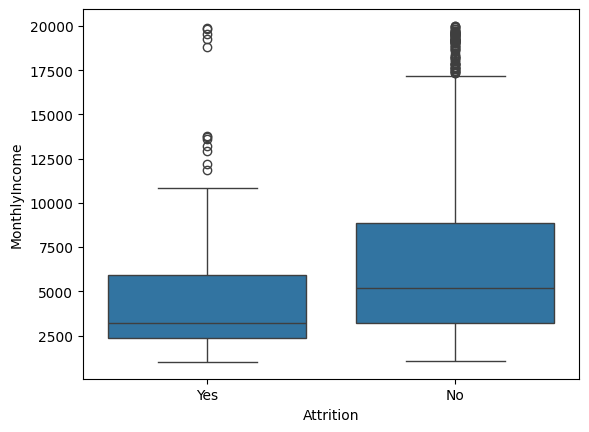

In [ ]:
#First you check single relationships of different categories with Attrition
import seaborn as sns
import matplotlib.pyplot as plt
#Attrition VS Monthly income
sns.boxplot(x='Attrition', y='MonthlyIncome', data=hr)
plt.show()

#Most staffs that have left have low income


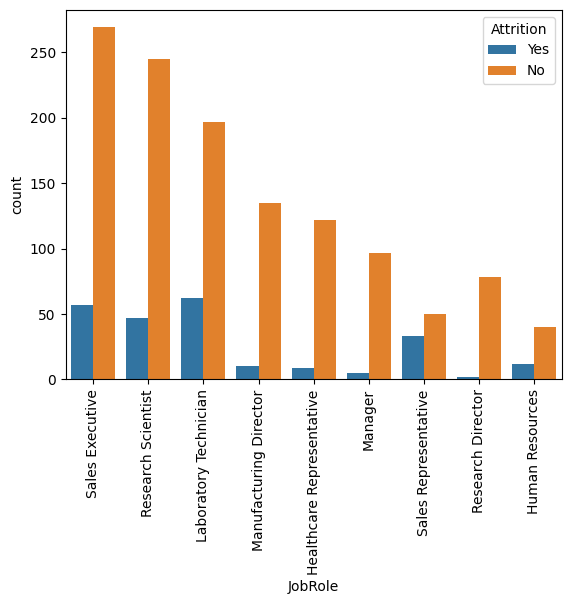

In [ ]:
#Attrition VS Job role
sns.countplot(x='JobRole', hue='Attrition', data=hr)
plt.xticks(rotation=90)
plt.show()

#Sales staff and Laboratory Staff have the most number of staffs leaving

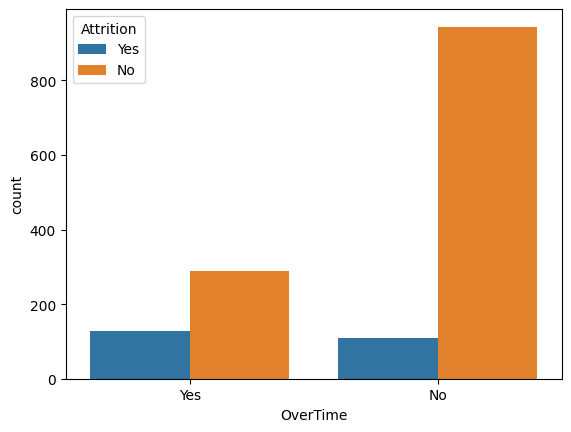

In [ ]:
#To check by overtime count
sns.countplot(x='OverTime', hue='Attrition', data=hr)
plt.show()

#Overtime rate has little impact

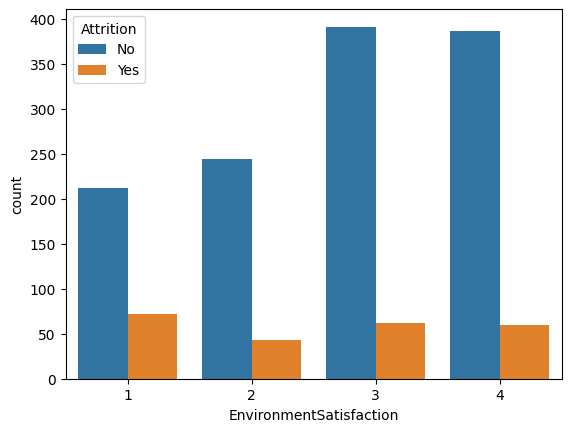

In [ ]:
#To check enviroment satisfaction
sns.countplot(x='EnvironmentSatisfaction', hue='Attrition', data=hr)
plt.show()

#Enviroment satisfaction has a little impact

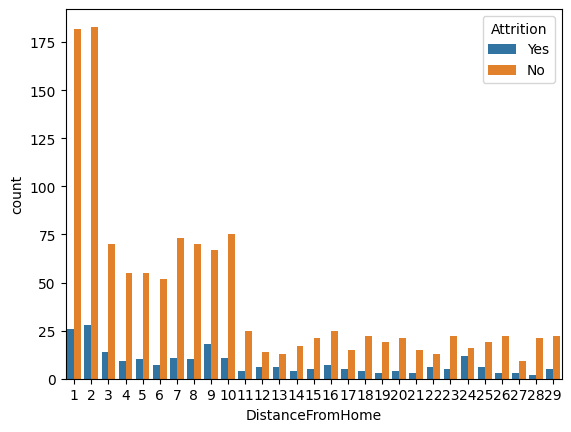

In [ ]:
#To check percentage of attrition relating distance from home
sns.countplot(x='DistanceFromHome', hue='Attrition', data=hr)
plt.show()


#Distance from home has a little relationship and that is that most of the employees that stayed live close to work

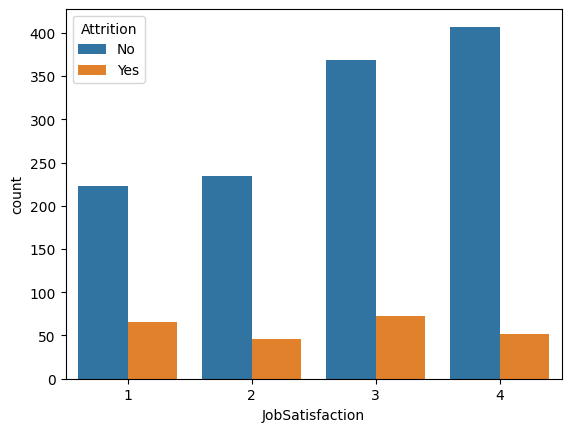

In [ ]:
#To check job satisfaction
sns.countplot(x='JobSatisfaction', hue='Attrition', data=hr)
plt.show()

#There is a little or no pattern for people that left

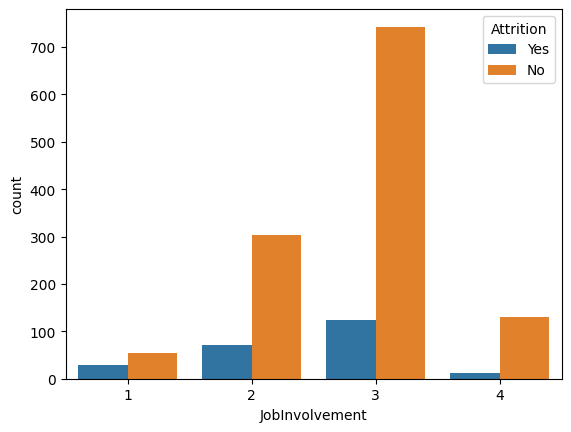

In [ ]:
#To check for job involvement
sns.countplot(x='JobInvolvement', hue='Attrition', data=hr)
plt.show()

#A high count of employees thaat left were very much involved in work activities

From the analysis monthly income seemed to be the major reason while staffs left the company. Most of the staffs aare either sales or laboratory staffs.

# Prediction of Attrition


In [ ]:
#Preprocessing the data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#To encode the columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

#to encode all categorical columns
for col in hr.select_dtypes(include='object').columns:
    hr[col] = le.fit_transform(hr[col])

In [ ]:
#To train the model using a random forest since most of the relationsships are not linear
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = hr.drop('Attrition', axis=1)
y = hr['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
#To evaluate the model
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       256
           1       0.69      0.24      0.35        38

    accuracy                           0.89       294
   macro avg       0.79      0.61      0.65       294
weighted avg       0.87      0.89      0.86       294



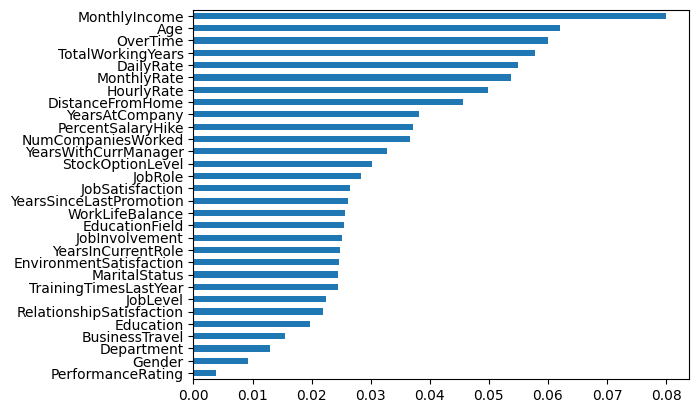

In [ ]:
#To check the features that are important

import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.show()

# Concluding statement

In this project, I analyzed employee attrition using Random Forest to identify the key factors influencing turnover. The analysis revealed that Overtime, Monthly Income, and Job Role are the strongest drivers of attrition. These insights provide actionable recommendations for HR teams to improve employee retention and guide data-driven decision-making within the organization.